<a href="https://colab.research.google.com/github/JakeEisner/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%205/Assignment_5_The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment 5: The Sovereign Risk Engine
Regularization, Classification, and Model Evaluation for Macroeconomic Early Warning Systems
Role: Quantitative Economist | Organization: IMF Global Financial Stability Division | Platform: Google Colab (Python 3.10+)



In [1]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas -q

In [2]:
# Required libraries
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
    r2_score,
    mean_squared_error,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

In [3]:
# Shared Data Pipeline | Same WDI Indicators from Lab 16

INDICATORS = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade
    'NE.TRD.GNFS.ZS':       'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':       'royalties_receipts',

    # Macro
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':        'real_interest_rate',
    'PA.NUS.FCRF':        'exchange_rate_official',

    # Education
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure
    'IT.NET.USER.ZS':  'internet_users_pct',
    'IT.CEL.SETS.P2':  'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':  'electricity_access_pct',
    'IS.ROD.PAVE.ZS':  'paved_roads_pct',

    # Health
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Resources & Agriculture
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance
    'IQ.CPA.TRAD.XQ':  'trade_cpia',
    'IQ.CPA.FINS.XQ':  'financial_management_cpia',
    'IQ.CPA.PROP.XQ':  'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

# download 2013-2019 data
print(f"Downloading {len(indicator_list)} indicators... (may take ~30-60 sec)")

raw_data = wb.data.DataFrame(
    indicator_list,
    time=range(2013, 2020),
    skipBlanks=True,
    labels=False
)
raw_data.columns = [INDICATORS.get(c, c) for c in raw_data.columns]

# collapse to country-level means
if isinstance(raw_data.index, pd.MultiIndex):
    country_data = raw_data.mean(axis=1).unstack(level='series').rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

# drop countries/indicators missing more than 40%
thresh = 0.60
country_data = country_data.dropna(thresh=int(thresh * country_data.shape[1]))
country_data = country_data.dropna(axis=1, thresh=int(thresh * len(country_data)))

# median impute remaining gaps
country_data = country_data.fillna(country_data.median(numeric_only=True))

# binary crisis outcome: 1 if average gdp per capita growth was negative
country_data['crisis'] = (country_data[OUTCOME_VAR] < 0).astype(int)

# set up X, y
feature_cols = [c for c in country_data.columns if c not in (OUTCOME_VAR, 'crisis')]
feature_names = feature_cols

X        = country_data[feature_cols].values
y_cont   = country_data[OUTCOME_VAR].values
y_crisis = country_data['crisis'].values

# 70/30 split, random_state=42
X_train, X_test, y_train, y_test, y_crisis_train, y_crisis_test = train_test_split(
    X, y_cont, y_crisis, test_size=0.30, random_state=42
)

# standardize — fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# summary stats
n_total    = len(country_data)
n_crisis   = int(country_data['crisis'].sum())
base_rate  = n_crisis / n_total

print(f"\nFinal dataset: {n_total} countries x {len(feature_cols)} predictors")
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | p/n ratio: {len(feature_cols)/X_train.shape[0]:.2f}")
print(f"\nCrisis (y=1): {n_crisis} | No crisis (y=0): {n_total - n_crisis}")
print(f"Crisis base rate: {base_rate:.3f} ({base_rate:.1%})")


Final dataset: 238 countries x 28 predictors
Train: 166 | Test: 72 | p/n ratio: 0.17

Crisis (y=1): 38 | No crisis (y=0): 200
Crisis base rate: 0.160 (16.0%)


In [4]:
# Question 1, 1.1

ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

ols_train_r2 = r2_score(y_train, ols.predict(X_train_scaled))
ols_test_r2 = r2_score(y_test, ols.predict(X_test_scaled))
ols_test_rmse = np.sqrt(mean_squared_error(y_test, ols.predict(X_test_scaled)))
p = X_train_scaled.shape[1]
n = X_train_scaled.shape[0]

print(f'Train R^2: {ols_train_r2:.3f}')
print(f'Test R^2: {ols_test_r2:.3f}')
print(f'R^2 Gap:  {(ols_train_r2 - ols_test_r2):.3f}')
print(f'\np/n ratio: {p}/{n} = {p/n:.2f}')

Train R^2: 0.603
Test R^2: -0.914
R^2 Gap:  1.517

p/n ratio: 28/166 = 0.17


The p/n ratio of 0.17 means OLS is estimating 28 coefficients from only 166 observations. Even though 0.17 is not that high, WDI indicators are heavily correlated with each other, which effectively uses up degrees of freedom and lets OLS fit noise in the training data rather than real signal. This drives variance way up, and since OLS applies no bias to constrain the coefficients, the model completely falls apart on new data: training R² is 0.603 but test R² drops to -0.914, a gap of 1.517.

In [5]:
# Step 1.2

alphas = np.logspace(-3,3,100)
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_scaled, y_train)

lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train_scaled, y_train)

ridge_train_r2 = r2_score(y_train, ridge.predict(X_train_scaled))
ridge_test_r2 = r2_score(y_test, ridge.predict(X_test_scaled))
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_scaled)))

lasso_train_r2 = r2_score(y_train, lasso.predict(X_train_scaled))
lasso_test_r2 = r2_score(y_test, lasso.predict(X_test_scaled))
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_scaled)))

lasso_nonzero = np.sum(lasso.coef_ != 0)

comparison = pd.DataFrame({
    'Model':               ['OLS', 'Ridge', 'Lasso'],
    'Lambda*':             ['N/A', f'{ridge.alpha_:.4f}', f'{lasso.alpha_:.4f}'],
    'Non-zero Predictors': [p, p, lasso_nonzero],
    'Train R²':            [f'{ols_train_r2:.3f}', f'{ridge_train_r2:.3f}', f'{lasso_train_r2:.3f}'],
    'Test R²':             [f'{ols_test_r2:.3f}',  f'{ridge_test_r2:.3f}',  f'{lasso_test_r2:.3f}'],
    'Test RMSE':           [f'{ols_test_rmse:.3f}', f'{ridge_test_rmse:.3f}', f'{lasso_test_rmse:.3f}']
})

print(comparison.to_string(index=False))

Model Lambda*  Non-zero Predictors Train R² Test R² Test RMSE
  OLS     N/A                   28    0.603  -0.914     2.923
Ridge 46.4159                   28    0.560  -0.073     2.188
Lasso  0.0658                   18    0.574  -0.357     2.460


Ridge is the better choice for operational GDP growth forecasting. Both models deliberately introduce some bias by shrinking coefficients toward zero, and in return they bring variance down significantly compared to OLS. Ridge's test R² improves from -0.914 to -0.065 and RMSE drops from 2.923 to 2.180, while Lasso only gets to -0.348, likely because several WDI indicators are correlated and Lasso arbitrarily zeroes one out when two predictors carry similar information, throwing away useful signal in the process.

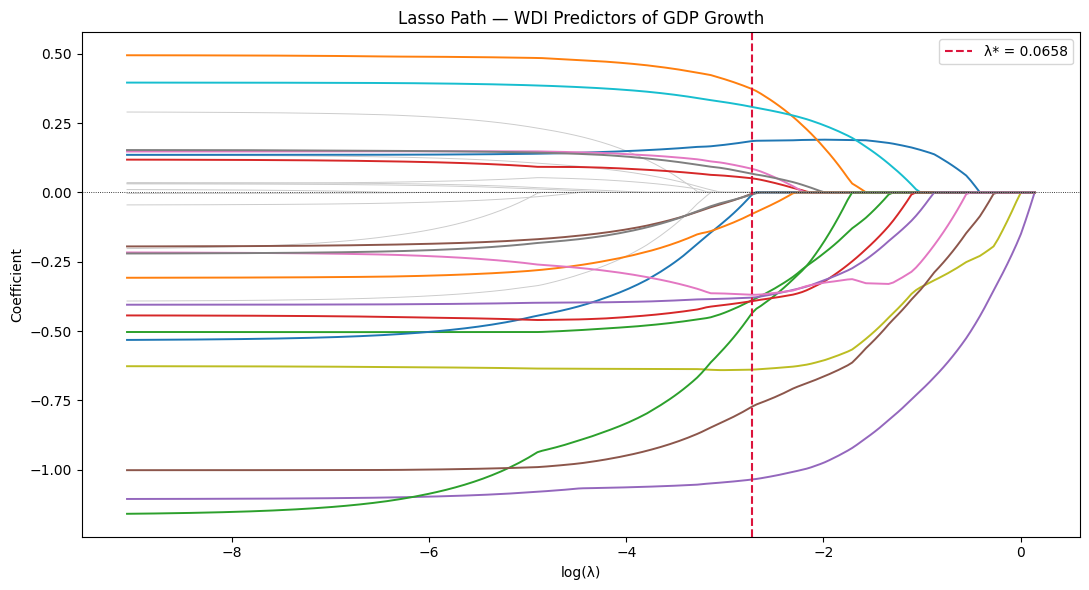

First predictor to enter: inflation_cpi at λ = 1.10182


In [6]:
# Step 1.3 | Lasso Path

alphas_path, coefficient_path, _ = lasso_path(X_train_scaled, y_train, eps=1e-4, n_alphas=200)

selected = np.abs(lasso.coef_) > 0

fig, ax = plt.subplots(figsize=(11, 6))

for i, name in enumerate(feature_names):
    if selected[i]:
        ax.plot(np.log(alphas_path), coefficient_path[i], lw=1.4, zorder=2)
    else:
        ax.plot(np.log(alphas_path), coefficient_path[i], color='#cccccc', lw=0.7, zorder=1)

ax.axvline(np.log(lasso.alpha_), color='crimson', ls='--', lw=1.5, label=f'λ* = {lasso.alpha_:.4f}')
ax.axhline(0, color='black', lw=0.6, ls=':')
ax.set_xlabel('log(λ)')
ax.set_ylabel('Coefficient')
ax.set_title('Lasso Path — WDI Predictors of GDP Growth')
ax.legend()
plt.tight_layout()
plt.show()

# first predictor to enter
entry_lambdas = []
for i in range(len(feature_names)):
    nonzero_idx = np.where(np.abs(coefficient_path[i]) > 1e-6)[0]
    if len(nonzero_idx) > 0:
        entry_lambdas.append((feature_names[i], alphas_path[nonzero_idx[0]]))

first_pred = max(entry_lambdas, key=lambda x: x[1])
print(f'First predictor to enter: {first_pred[0]} at λ = {first_pred[1]:.5f}')

First predictor explanation:

inflation_cpi enters first at λ = 1.10182, meaning it has the strongest unconditional relationship with GDP per capita growth across countries. This makes economic sense since high inflation is one of the clearest signs of macroeconomic instability, and countries with runaway inflation consistently show lower or negative growth regardless of their other characteristics.

Written response:
The colleague is wrong because Lasso zeroing out life_expectancy reflects conditional predictive redundancy, not economic irrelevance. WDI indicators have a dense correlation structure where life expectancy moves closely with infant mortality, education enrollment, and income level, so by the time those variables are already in the model, life_expectancy has no additional predictive signal left to contribute. Lasso can only see marginal predictive contribution given what else is in the model, so it drops one of the correlated variables arbitrarily. That says nothing about whether life expectancy has a real relationship with growth.

In [7]:
# Problem 2, Step 2.1

lasso_selected = np.where(lasso.coef_ != 0)[0]
X_train_lasso = X_train_scaled[:, lasso_selected]
X_test_lasso = X_test_scaled[:, lasso_selected]
lpm = LinearRegression()
lpm.fit(X_train_lasso, y_crisis_train)
lpm_pred = lpm.predict(X_test_lasso)


out_of_bounds = np.sum((lpm_pred < 0) | (lpm_pred > 1))
print(f'LPM predictions below 0 or above 1: {out_of_bounds} of {len(lpm_pred)}')
print(f'Min predicted value: {lpm_pred.min():.3f}')
print(f'Max predicted value: {lpm_pred.max():.3f}')

LPM predictions below 0 or above 1: 14 of 72
Min predicted value: -0.301
Max predicted value: 1.568


14 out of 72 test countries got predicted probabilities outside [0, 1], ranging from -0.301 to 1.568. This is a fundamental problem because a probability of -30% or 157% is mathematically meaningless and cannot be used to make any real decision. If the IMF received a negative crisis probability for a country, they would have no way to interpret or act on it, which defeats the entire purpose of the early warning system.

In [8]:
# Step 2.2

logit = LogisticRegression(max_iter=1000, random_state=42)
logit.fit(X_train_lasso, y_crisis_train)

lasso_feature_names = [feature_names[i] for i in lasso_selected]

coef_df = pd.DataFrame({
    'Feature': lasso_feature_names,
    'Beta': logit.coef_[0],
    'Odds Ratio': np.exp(logit.coef_[0])
}).sort_values('Odds Ratio', key=abs, ascending=False)

print(f'Intercept: {logit.intercept_[0]:.3f}')
print()
print(coef_df)

logit_prob = logit.predict_proba(X_test_lasso)[:,1]
print(f'\nMin predicted probability: {logit_prob.min():.4f}')
print(f'Max predicted probability: {logit_prob.max():.4f}')

Intercept: -3.026

                           Feature      Beta  Odds Ratio
15               population_growth  0.825074    2.282050
13      health_expenditure_pct_gdp  0.822688    2.276612
12        infant_mortality_per1000  0.743399    2.103072
8   natural_resource_rents_pct_gdp  0.729249    2.073522
17                 tariff_rate_avg  0.578947    1.784159
14               unemployment_rate  0.532429    1.703064
4                    inflation_cpi  0.494075    1.638982
2                     atms_per100k  0.368015    1.444864
6      mobile_subscriptions_per100  0.356114    1.427771
10             adult_literacy_rate  0.273696    1.314814
16                urbanization_pct  0.211874    1.235992
5         govt_expenditure_pct_gdp  0.131039    1.140012
9           exchange_rate_official -0.014787    0.985322
11       tertiary_enrollment_gross -0.073789    0.928867
3           private_credit_pct_gdp -0.078833    0.924194
7                    trade_pct_gdp -0.353088    0.702515
1           

A one standard-deviation increase in population growth multiplies the odds of crisis by 2.28, holding all else constant. This makes sense because rapid population growth puts pressure on an economy's ability to generate enough output per person, making negative GDP per capita growth more likely even if total GDP is expanding.

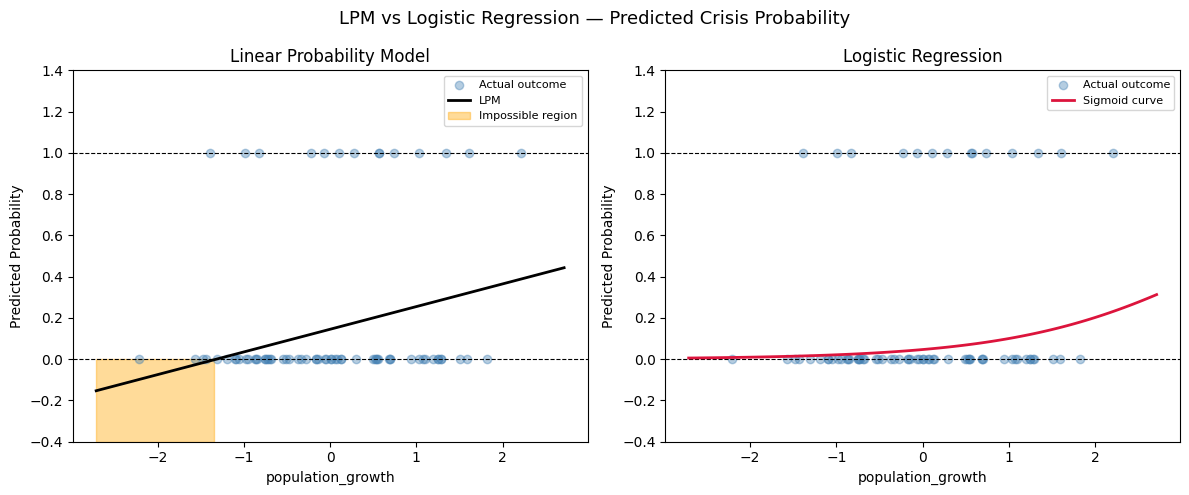

In [9]:
# Step 2.3 | LPM vs Logistic Visualization

predictor = 'population_growth'
predictor_idx = lasso_feature_names.index(predictor)

x_vals = X_test_lasso[:, predictor_idx]
x_range = np.linspace(x_vals.min() - 0.5, x_vals.max() + 0.5, 100)

x_plot = np.zeros((100, X_test_lasso.shape[1]))
x_plot[:, predictor_idx] = x_range
lpm_line = lpm.predict(x_plot)
logit_line = logit.predict_proba(x_plot)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LPM panel
ax = axes[0]
ax.scatter(x_vals, y_crisis_test, alpha=0.4, color='steelblue', zorder=2, label='Actual outcome')
ax.plot(x_range, lpm_line, color='black', lw=2, zorder=3, label='LPM')
ax.fill_between(x_range, -0.4, 0, where=(lpm_line < 0), color='orange', alpha=0.4, label='Impossible region')
ax.fill_between(x_range, 1, 1.4, where=(lpm_line > 1), color='orange', alpha=0.4)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axhline(1, color='black', lw=0.8, ls='--')
ax.set_ylim(-0.4, 1.4)
ax.set_xlabel(predictor)
ax.set_ylabel('Predicted Probability')
ax.set_title('Linear Probability Model')
ax.legend(fontsize=8)

# Logistic panel
ax = axes[1]
ax.scatter(x_vals, y_crisis_test, alpha=0.4, color='steelblue', zorder=2, label='Actual outcome')
ax.plot(x_range, logit_line, color='crimson', lw=2, zorder=3, label='Sigmoid curve')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axhline(1, color='black', lw=0.8, ls='--')
ax.set_ylim(-0.4, 1.4)
ax.set_xlabel(predictor)
ax.set_ylabel('Predicted Probability')
ax.set_title('Logistic Regression')
ax.legend(fontsize=8)

plt.suptitle('LPM vs Logistic Regression — Predicted Crisis Probability', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# 3.1

logit_pred = logit.predict(X_test_lasso)
test_base_rate = y_crisis_test.mean()
naive_actual  = (y_crisis_test == 0).mean()
naive_recall = 0.0
logit_actual = (logit_pred == y_crisis_test).mean()
logit_recall = recall_score(y_crisis_test, logit_pred)

print(f'Test crisis base rate: {test_base_rate:.3f} ({test_base_rate:.1%})')
print()
print(f'Naive baseline accuracy: {naive_actual:.3f}')
print(f'Naive baseline recall: {naive_recall:.3f}')
print()
print(f'Logistic accuracy (τ=0.5): {logit_actual:.3f}')
print(f'Logistic recall (τ=0.5): {logit_recall:.3f}')

Test crisis base rate: 0.194 (19.4%)

Naive baseline accuracy: 0.806
Naive baseline recall: 0.000

Logistic accuracy (τ=0.5): 0.764
Logistic recall (τ=0.5): 0.429


Written response: Reporting only accuracy would actually make the logistic model look worse than doing nothing, since the naive baseline scores 80.6% by just predicting no crisis for every country while the logistic model only hits 76.4%. This is the accuracy paradox: when 80% of the test set is non-crisis, a model that never raises an alarm gets most predictions right just by default. The Division Chief would be badly misled because the naive baseline has zero recall, meaning it would miss every single crisis, which is exactly the outcome the IMF is trying to prevent.



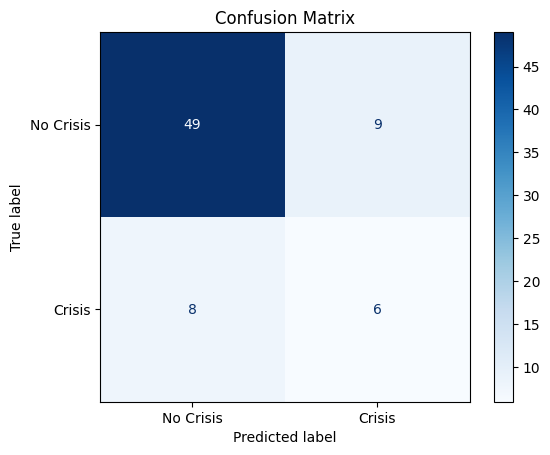

              precision    recall  f1-score   support

   No Crisis       0.86      0.84      0.85        58
      Crisis       0.40      0.43      0.41        14

    accuracy                           0.76        72
   macro avg       0.63      0.64      0.63        72
weighted avg       0.77      0.76      0.77        72

True Positives  (crises flagged):  6
False Negatives (crises missed):   8
False Positives (false alarms):    9
True Negatives  (correct no flag): 49


In [11]:
# Step 3.2

c_matrix = confusion_matrix(y_crisis_test, logit_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=c_matrix, display_labels=['No Crisis', 'Crisis'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_crisis_test, logit_pred, target_names=['No Crisis', 'Crisis']))

tn, fp, fn, tp = c_matrix.ravel()
print(f"True Positives  (crises flagged):  {tp}")
print(f"False Negatives (crises missed):   {fn}")
print(f"False Positives (false alarms):    {fp}")
print(f"True Negatives  (correct no flag): {tn}")

A False Negative is far more costly in this context since missing a real crisis carries an estimated $50 billion price tag in contagion and emergency lending, compared to just $2 million for a false alarm. With 8 crises missed and only 6 caught at the default threshold, the model is currently failing at its most important job. This asymmetry means the Division Chief should prioritize Recall over Precision, since Recall measures how many actual crises the model catches and a low Recall directly translates to sovereign defaults the IMF failed to prevent.

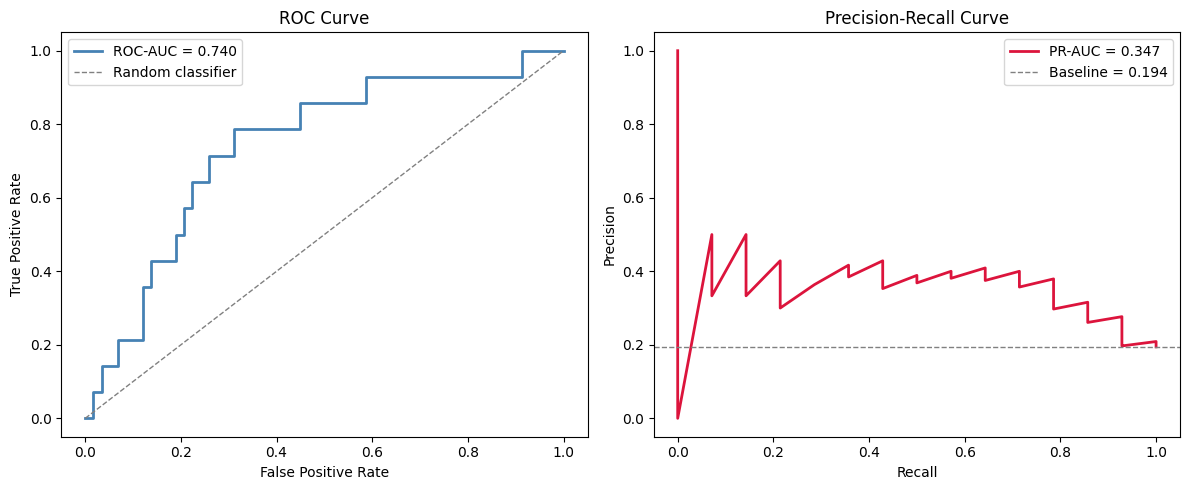

ROC-AUC: 0.740
PR-AUC:  0.347


In [12]:
# Step 3.3 ROC and Precision-Recall Curves

fpr, tpr, _ = roc_curve(y_crisis_test, logit_prob)
roc_auc = roc_auc_score(y_crisis_test, logit_prob)

precision, recall, _ = precision_recall_curve(y_crisis_test, logit_prob)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1,2, figsize=(12,5))

# Panel
ax = axes[0]
ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], color='gray', lw=1, ls='--', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

# PR panel
ax = axes[1]
ax.plot(recall, precision, color='crimson', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
ax.axhline(test_base_rate, color='gray', lw=1, ls='--', label=f'Baseline = {test_base_rate:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC:  {pr_auc:.3f}")


Written response: The ROC-AUC of 0.740 is much higher than the PR-AUC of 0.347 because ROC curve performance is inflated by the large number of True Negatives in the dataset. With 80% of countries being non-crisis, the model correctly rules out a lot of them, which makes the FPR stay low and pushes the ROC curve up even when crisis detection is weak. The PR curve ignores True Negatives entirely and only looks at how well the model actually finds crisis countries, which is why it tells a much harsher story. For the IMF's mission the PR curve is more informative since the whole point is catching crises, not getting credit for correctly identifying stable countries.

Capacity-constrained threshold: 0.88
  Countries flagged: 5
  Precision:         0.400
  Recall:            0.143

F1-optimal threshold: 0.13
  Countries flagged: 25
  Precision:         0.400
  Recall:            0.714
  F1:                0.513


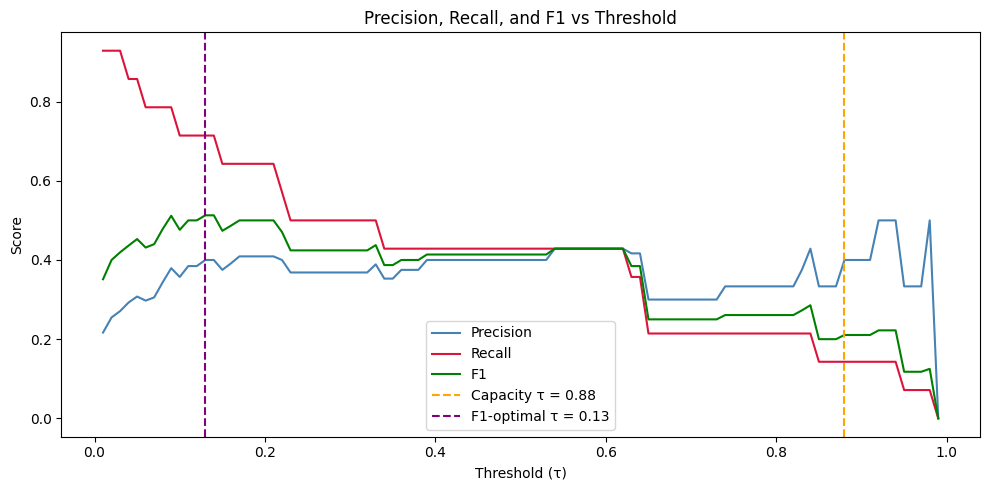

In [13]:
# Step 3.4 Threshold Analysis

thresholds = np.arange(0.01, 1.0, 0.01)

precisions, recalls, f1s, flagged = [], [], [], []

for tau in thresholds:
    preds = (logit_prob >= tau).astype(int)
    flagged.append(preds.sum())
    precisions.append(precision_score(y_crisis_test, preds, zero_division=0))
    recalls.append(recall_score(y_crisis_test, preds, zero_division=0))
    f1s.append(f1_score(y_crisis_test, preds, zero_division=0))

precisions = np.array(precisions)
recalls = np.array(recalls)
f1s = np.array(f1s)
flagged = np.array(flagged)

valid = np.where(flagged <= 5)[0]
cap_idx = valid[0]
cap_tau = thresholds[cap_idx]

f1_idx = np.argmax(f1s)
f1_tau = thresholds[f1_idx]

print(f"Capacity-constrained threshold: {cap_tau:.2f}")
print(f"  Countries flagged: {flagged[cap_idx]}")
print(f"  Precision:         {precisions[cap_idx]:.3f}")
print(f"  Recall:            {recalls[cap_idx]:.3f}")
print()
print(f"F1-optimal threshold: {f1_tau:.2f}")
print(f"  Countries flagged: {flagged[f1_idx]}")
print(f"  Precision:         {precisions[f1_idx]:.3f}")
print(f"  Recall:            {recalls[f1_idx]:.3f}")
print(f"  F1:                {f1s[f1_idx]:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions, label='Precision', color='steelblue')
ax.plot(thresholds, recalls, label='Recall', color='crimson')
ax.plot(thresholds, f1s, label='F1', color='green')
ax.axvline(cap_tau, color='orange', ls='--', label=f'Capacity τ = {cap_tau:.2f}')
ax.axvline(f1_tau, color='purple', ls='--', label=f'F1-optimal τ = {f1_tau:.2f}')
ax.set_xlabel('Threshold (τ)')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1 vs Threshold')
ax.legend()
plt.tight_layout()
plt.show()

We recommend the F1-optimal threshold of τ = 0.13. At this threshold the model catches 10 of 14 crisis countries in the test set, compared to only 2 at the capacity-constrained threshold of 0.88. The tradeoff is that 25 countries get flagged instead of 5, but given that a missed crisis costs 50 billion versus $2 million for a false alarm, the IMF should prioritize recall and find a way to handle the additional flags.

**P.R.I.M.E. Prompt — Task 4.1: Bootstrap Lasso Stability**

**Prep:** I have a training dataset X_train_scaled (166 x 28 standardized features) and y_train (continuous GDP per capita growth). I already have LassoCV imported from sklearn.

**Request:** Write a Python script that draws 200 bootstrap resamples with replacement from the training data, fits LassoCV on each resample, and records which features get non-zero coefficients. Then compute the selection frequency for each predictor (fraction of 200 runs where it was selected) and plot a horizontal bar chart ranked by selection frequency with a vertical reference line at 50%.

**Iterate:** Use the same feature_names list I already have defined. Use random_state seeds based on the loop index for reproducibility.

**Mechanism Check:** LassoCV should use cv=5 and max_iter=10000. A feature counts as selected if its coefficient is non-zero.

**Evaluate:** The chart should clearly show which predictors are stable (selected >80% of bootstraps) and which are fragile (<30%).

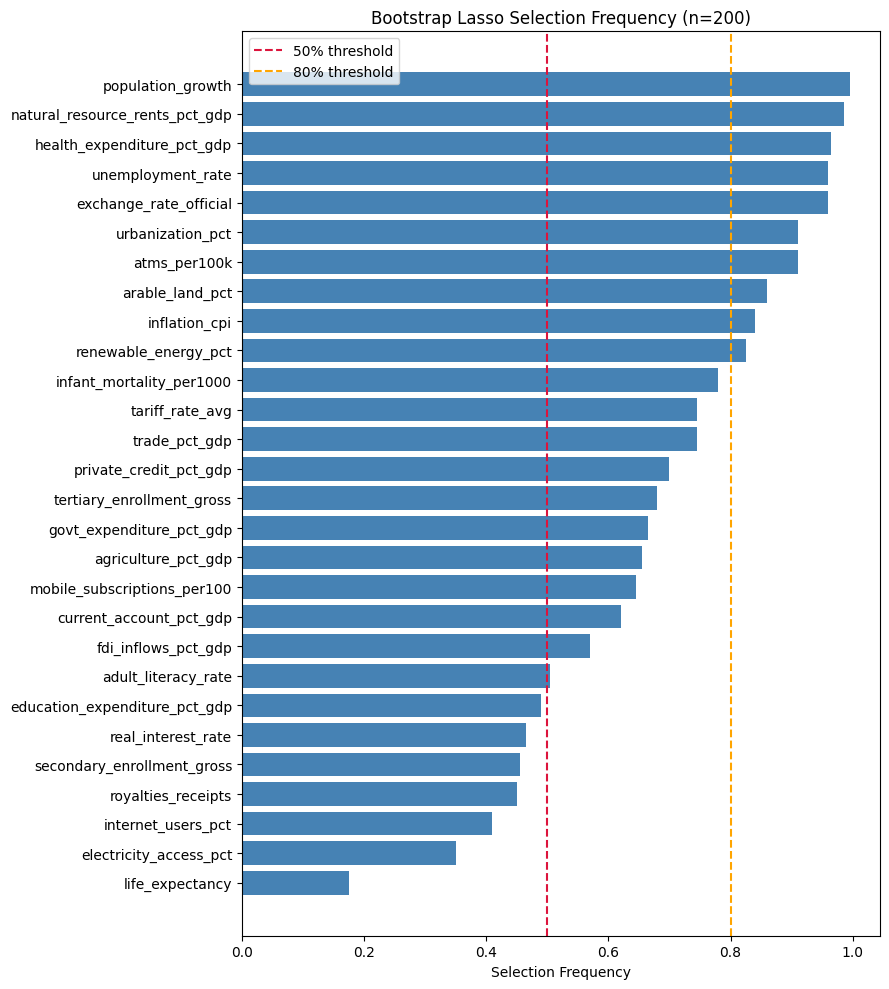

Stable predictors (>80%):
                       Feature  Selection Frequency
          renewable_energy_pct                0.825
                 inflation_cpi                0.840
               arable_land_pct                0.860
                  atms_per100k                0.910
              urbanization_pct                0.910
        exchange_rate_official                0.960
             unemployment_rate                0.960
    health_expenditure_pct_gdp                0.965
natural_resource_rents_pct_gdp                0.985
             population_growth                0.995

Fragile predictors (<30%):
        Feature  Selection Frequency
life_expectancy                0.175


In [14]:
# Task 4.1 | Bootstrap Lasso Stability

n_bootstraps = 200
selection_counts = np.zeros(len(feature_names))

for i in range(n_bootstraps):
    rng = np.random.RandomState(i)
    idx = rng.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    X_boot = X_train_scaled[idx]
    y_boot = y_train[idx]

    boot_lasso = LassoCV(cv=5, max_iter=10000, random_state=i)
    boot_lasso.fit(X_boot, y_boot)
    selection_counts += (boot_lasso.coef_ != 0).astype(int)

selection_freq = selection_counts / n_bootstraps

freq_df = pd.DataFrame({
    'Feature': feature_names,
    'Selection Frequency': selection_freq
}).sort_values('Selection Frequency', ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(freq_df['Feature'], freq_df['Selection Frequency'], color='steelblue')
ax.axvline(0.5, color='crimson', ls='--', lw=1.5, label='50% threshold')
ax.axvline(0.8, color='orange', ls='--', lw=1.5, label='80% threshold')
ax.set_xlabel('Selection Frequency')
ax.set_title('Bootstrap Lasso Selection Frequency (n=200)')
ax.legend()
plt.tight_layout()
plt.show()

print("Stable predictors (>80%):")
print(freq_df[freq_df['Selection Frequency'] > 0.8][['Feature', 'Selection Frequency']].to_string(index=False))
print("\nFragile predictors (<30%):")
print(freq_df[freq_df['Selection Frequency'] < 0.3][['Feature', 'Selection Frequency']].to_string(index=False))

The stable predictors selected in over 80% of bootstraps are population_growth, natural_resource_rents_pct_gdp, health_expenditure_pct_gdp, unemployment_rate, exchange_rate_official, urbanization_pct, atms_per100k, arable_land_pct, inflation_cpi, and renewable_energy_pct. The only fragile predictor is life_expectancy at 17.5%, meaning Lasso almost never picks it when the sample changes slightly. This instability reflects the dense correlation structure of WDI indicators — life_expectancy overlaps heavily with health expenditure, infant mortality, and urbanization, so whichever of those enters the model first absorbs its signal and leaves life_expectancy with nothing to contribute.

**P.R.I.M.E. Prompt — Task 4.2: Cost-Sensitive Threshold Optimization**

**Prep:** I have logit_prob (predicted probabilities from a logistic regression on the test set) and y_crisis_test (binary crisis labels). I already have numpy and matplotlib imported.

**Request:** Write a Python script that sweeps thresholds from 0.01 to 0.99 in steps of 0.01. At each threshold compute the total expected cost using FN x $50 billion + FP x $2 million. Plot the expected cost curve as a function of tau and annotate the cost-minimizing threshold on the plot.

**Iterate:** Use confusion_matrix from sklearn to extract FN and FP counts at each threshold. Express costs in billions for readability on the y-axis.

**Mechanism Check:** FN is the count of actual crisis countries the model misses. FP is the count of non-crisis countries incorrectly flagged. The cost formula weights FN at 25,000x more than FP.

**Evaluate:** The plot should clearly show the minimum point with a vertical line and text annotation showing the optimal tau and its total cost.

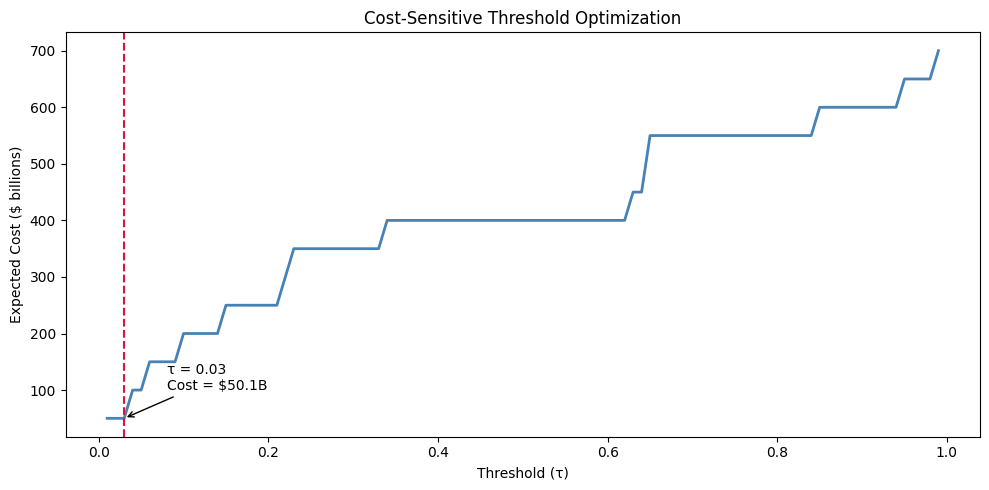

Cost-minimizing threshold: 0.03
Total expected cost: $50.07 billion


In [15]:
# Task 4.2 | Cost-Sensitive Threshold Optimization

cost_fn = 50      # $50 billion per missed crisis
cost_fp = 0.002   # $2 million = 0.002 billion per false alarm

thresholds_cost = np.arange(0.01, 1.0, 0.01)
total_costs = []

for tau in thresholds_cost:
    preds = (logit_prob >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_crisis_test, preds).ravel()
    total_costs.append(fn * cost_fn + fp * cost_fp)

total_costs = np.array(total_costs)
min_idx = np.argmin(total_costs)
min_tau = thresholds_cost[min_idx]
min_cost = total_costs[min_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_cost, total_costs, color='steelblue', lw=2)
ax.axvline(min_tau, color='crimson', ls='--', lw=1.5)
ax.annotate(f'τ = {min_tau:.2f}\nCost = ${min_cost:.1f}B',
            xy=(min_tau, min_cost),
            xytext=(min_tau + 0.05, min_cost + 50),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)
ax.set_xlabel('Threshold (τ)')
ax.set_ylabel('Expected Cost ($ billions)')
ax.set_title('Cost-Sensitive Threshold Optimization')
plt.tight_layout()
plt.show()

print(f"Cost-minimizing threshold: {min_tau:.2f}")
print(f"Total expected cost: ${min_cost:.2f} billion")

The cost-minimizing threshold of τ = 0.03 is much lower than both the F1-optimal threshold of 0.13 and the capacity-constrained threshold of 0.88 because it is driven entirely by the massive asymmetry between a $50 billion missed crisis and a $2 million false alarm. F1 treats precision and recall as roughly equal in importance, and the capacity constraint ignores costs entirely, so both end up at higher thresholds that miss more crises. The cost-minimizing threshold is the right recommendation for the IMF since it reflects the actual stakes involved, even though flagging nearly every country at τ = 0.03 would require a serious expansion of mission capacity.